<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Naive Bayes for Spam Detection</b>
</h1>
<div style="font-family:'Times New Roman';">
<b>Goal:</b>
<ol>
<li>Apply Naive Bayes to a real-world text classification problem - spam detection.</li>
<li>Understand how text gets converted into numbers (Bag of Words / TF-IDF).</li>
<li>Understand why Multinomial Naive Bayes is suited for text data.</li>
<li>Train, evaluate, and test the model on real messages.</li>
</ol>
In the previous notebooks, I worked with categorical and continuous (Gaussian) 
Naive Bayes. Now I'll apply it to <b>text data</b> which is one of the most popular 
real-world use cases for Naive Bayes.
</div>

In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Loading the SMS Spam Dataset</b>
</h2>
<div style="font-family:'Times New Roman';">
I'll use the classic <b>SMS Spam Collection</b> dataset - a set of 
text messages labeled as either <b>"ham"</b> (normal message) or 
<b>"spam"</b> (unwanted/promotional message).
<br><br>
This dataset is commonly available online as a tab-separated file 
with two columns: the label and the message text.
</div>

In [3]:
# Loading the dataset directly from a public URL
# The file is tab-separated with no header, so we specify column names manually

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print("Shape of data:", df.shape)
df.head()

Shape of data: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Exploring the Data</b>
</h2>
<div style="font-family:'Times New Roman';">
Before building the model, let's check:
<ul>
<li>How many spam vs ham messages are there?</li>
<li>What do typical spam vs ham messages look like?</li>
</ul>
</div>

label
ham     4825
spam     747
Name: count, dtype: int64

Percentage:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


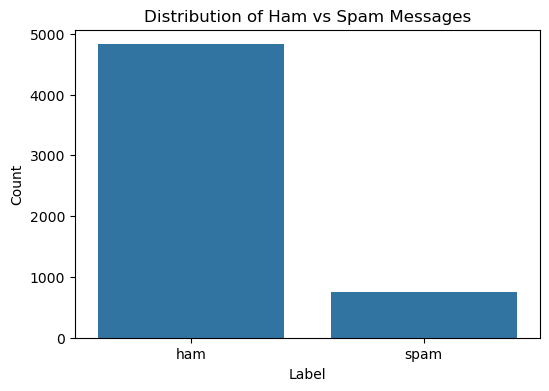

In [4]:
# Checking the distribution of labels
print(df['label'].value_counts())
print("\nPercentage:")
print(df['label'].value_counts(normalize=True) * 100)

# Visualizing
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title("Distribution of Ham vs Spam Messages")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [5]:
# Printing a few examples of each type
print("Sample HAM messages:\n")
for msg in df[df['label'] == 'ham']['message'].head(3):
    print("-", msg)

print("\nSample SPAM messages:\n")
for msg in df[df['label'] == 'spam']['message'].head(3):
    print("-", msg)

Sample HAM messages:

- Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
- Ok lar... Joking wif u oni...
- U dun say so early hor... U c already then say...

Sample SPAM messages:

- Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
- FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv
- WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>From Text to Numbers: Bag of Words</b>
</h2>
<div style="font-family:'Times New Roman';">
Naive Bayes (and basically all ML algorithms) can't work directly 
with raw text - it needs numbers. The simplest way to convert text 
into numbers is the <b>Bag of Words</b> model:
<br><br>
<ol>
<li>Build a <b>vocabulary</b> of all unique words across all messages.</li>
<li>Represent each message as a vector of <b>word counts</b> - 
how many times each vocabulary word appears in that message.</li>
</ol>
This is called "bag of words" because we completely ignore 
<b>grammar and word order</b> - we just care about which words 
appear and how often.
<br><br>
This is also exactly why <b>Multinomial Naive Bayes</b> is the 
right choice here - it's designed for <b>count data</b> 
(like word frequencies).
</div>

In [6]:
# A tiny example to show how CountVectorizer works
example_messages = [
    "Win money now",
    "Win a free prize now",
    "Hi, are we still meeting today?"
]

# Creating a CountVectorizer and fitting it on these example messages
demo_vectorizer = CountVectorizer()
demo_matrix = demo_vectorizer.fit_transform(example_messages)

# Showing the vocabulary it learned
print("Vocabulary:", demo_vectorizer.get_feature_names_out())

# Showing the word-count matrix
demo_df = pd.DataFrame(demo_matrix.toarray(), 
                        columns=demo_vectorizer.get_feature_names_out())
demo_df

Vocabulary: ['are' 'free' 'hi' 'meeting' 'money' 'now' 'prize' 'still' 'today' 'we'
 'win']


,are,free,hi,meeting,money,now,prize,still,today,we,win
0,0,0,0,0,1,1,0,0,0,0,1
1,0,1,0,0,0,1,1,0,0,0,1
2,1,0,1,1,0,0,0,1,1,1,0


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Splitting the Data</b>
</h2>
<div style="font-family:'Times New Roman';">
Now let's split our actual dataset into training and testing sets, 
just like before. It's important to split <b>before</b> vectorizing - 
the vectorizer should only learn its vocabulary from the training data, 
to avoid any information from the test set leaking in.
</div>

In [7]:
# Separating features (messages) and labels
X = df['message']
y = df['label']

# Splitting into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 4457
Testing set size: 1115


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Converting Messages into Word Count Vectors</b>
</h2>
<div style="font-family:'Times New Roman';">
Now I'll use <b>CountVectorizer</b> on our actual messages:
<ul>
<li><b>fit_transform()</b> on training data - learns the vocabulary 
AND converts the training messages to vectors.</li>
<li><b>transform()</b> on test data - uses the SAME vocabulary 
(no re-learning) to convert test messages.</li>
</ul>
</div>

In [8]:
# Creating the vectorizer
vectorizer = CountVectorizer(stop_words='english')

# Learning vocabulary from training data and transforming it
X_train_counts = vectorizer.fit_transform(X_train)

# Transforming test data using the SAME vocabulary
X_test_counts = vectorizer.transform(X_test)

print("Shape of training data (messages x vocabulary size):", X_train_counts.shape)
print("Shape of testing data:", X_test_counts.shape)
print("\nVocabulary size:", len(vectorizer.get_feature_names_out()))
print("First 20 words in vocabulary:", vectorizer.get_feature_names_out()[:20])

Shape of training data (messages x vocabulary size): (4457, 7403)
Shape of testing data: (1115, 7403)

Vocabulary size: 7403
First 20 words in vocabulary: ['00' '000' '000pes' '008704050406' '0089' '0121' '01223585236'
 '01223585334' '02' '0207' '02072069400' '02073162414' '02085076972' '021'
 '03' '04' '0430' '05' '050703' '0578']


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Training Multinomial Naive Bayes</b>
</h2>
<div style="font-family:'Times New Roman';">
Now I'll train a <b>Multinomial Naive Bayes</b> classifier on the 
word-count vectors. Behind the scenes, this is doing exactly what 
we did manually in the previous notebook - calculating 
<b>P(word | class)</b> for every word in the vocabulary, and 
<b>P(class)</b> as the prior.
<br><br>
sklearn's implementation also includes <b>Laplace smoothing</b> 
by default (the <code>alpha=1.0</code> parameter) - solving the 
zero probability problem we discussed earlier.
</div>

In [9]:
# Creating and training the model
model = MultinomialNB(alpha=1.0)
model.fit(X_train_counts, y_train)

print("Model trained successfully!")

Model trained successfully!


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Evaluating the Model</b>
</h2>
<div style="font-family:'Times New Roman';">
Let's see how well our model performs on the unseen test messages.
</div>

In [10]:
# Making predictions on the test set
y_pred = model.predict(X_test_counts)

# Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

# Printing classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 98.48%

Classification Report:

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.98      0.98      0.98      1115



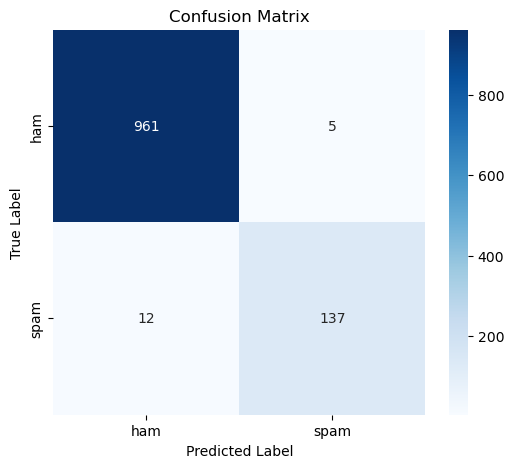

In [11]:
# Computing and visualizing the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam'],
            yticklabels=['ham', 'spam'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>A Quick Note on Precision vs Recall for Spam Detection</b>
</h2>
<div style="font-family:'Times New Roman';">
For spam detection, the <b>cost of different mistakes is not equal</b>:
<ul>
<li><b>False Positive</b> (a real "ham" message marked as spam): 
Bad! You might miss an important email.</li>
<li><b>False Negative</b> (a "spam" message marked as ham): 
Annoying, but less harmful - you just see one extra spam message.</li>
</ul>
This means for spam filters, we often care more about 
<b>precision for the "spam" class</b> - we want to be very 
confident before marking something as spam.
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Which Words Are Most "Spammy"?</b>
</h2>
<div style="font-family:'Times New Roman';">
One nice thing about Naive Bayes is that it's very 
<b>interpretable</b>. We can directly look at which words the model 
found most strongly associated with spam.
<br><br>
The model stores <b>log probabilities</b> of each word given each 
class in <code>model.feature_log_prob_</code>. A higher value means 
that word is more common in that class.
<br><br>
Let's find the top words for "spam" and compare them to "ham".
</div>

In [12]:
# Getting feature names (the vocabulary) and log probabilities
feature_names = np.array(vectorizer.get_feature_names_out())

# model.classes_ gives us the order of classes (e.g., ['ham', 'spam'])
print("Class order:", model.classes_)

# Getting log probabilities for each class
ham_log_probs = model.feature_log_prob_[0]   # P(word | ham)
spam_log_probs = model.feature_log_prob_[1]  # P(word | spam)

# Finding the top 15 words most associated with spam
top_spam_idx = np.argsort(spam_log_probs)[-15:]
top_spam_words = feature_names[top_spam_idx]

# Finding the top 15 words most associated with ham
top_ham_idx = np.argsort(ham_log_probs)[-15:]
top_ham_words = feature_names[top_ham_idx]

print("\nTop words associated with SPAM:")
print(top_spam_words)

print("\nTop words associated with HAM:")
print(top_ham_words)

Class order: ['ham' 'spam']

Top words associated with SPAM:
['send' 'just' 'won' 'uk' 'cash' 'prize' 'www' 'reply' 'mobile' 'claim'
 'text' 'stop' 'ur' 'txt' 'free']

Top words associated with HAM:
['want' 'time' 'love' 'like' 'day' 'ur' 'come' 'good' 'know' 'got' 'll'
 'ok' 'just' 'lt' 'gt']


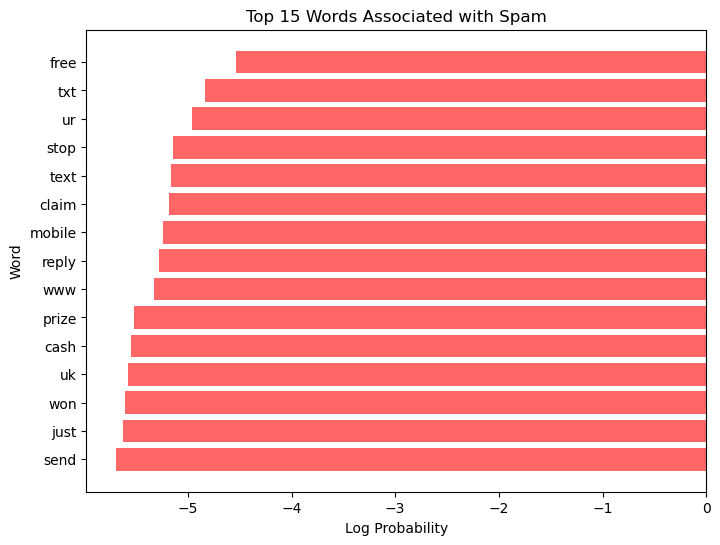

In [13]:
# Visualizing the top spam words and their log probabilities
plt.figure(figsize=(8, 6))
plt.barh(top_spam_words, spam_log_probs[top_spam_idx], color='#FF6666')

plt.title("Top 15 Words Associated with Spam")
plt.xlabel("Log Probability")
plt.ylabel("Word")
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Testing on Custom Messages</b>
</h2>
<div style="font-family:'Times New Roman';">
Let's test the model on a few messages we write ourselves - 
some that "sound like" spam, and some that "sound like" normal 
messages - and see what the model predicts.
</div>

In [15]:
# Writing some custom test messages
custom_messages = [
    "Congratulations! You've won a free iPhone, click here to claim now!",
    "Hey, are we still on for lunch tomorrow?",
    "URGENT: Your account has been suspended. Verify immediately to avoid loss.",
    "Can you send me the notes from today's class?",
    "Free entry to win a brand new car, text WIN to 12345 now!"
]

# Transforming using the SAME vectorizer (trained vocabulary)
custom_counts = vectorizer.transform(custom_messages)

# Predicting
custom_predictions = model.predict(custom_counts)

# Printing results
for msg, pred in zip(custom_messages, custom_predictions):
    print(f"[{pred.upper()}]  {msg}")

[SPAM]  Congratulations! You've won a free iPhone, click here to claim now!
[HAM]  Hey, are we still on for lunch tomorrow?
[SPAM]  URGENT: Your account has been suspended. Verify immediately to avoid loss.
[HAM]  Can you send me the notes from today's class?
[SPAM]  Free entry to win a brand new car, text WIN to 12345 now!


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>CountVectorizer vs TF-IDF</b>
</h2>
<div style="font-family:'Times New Roman';">
Instead of raw word counts, <b>TF-IDF</b> (Term Frequency - Inverse 
Document Frequency) weighs words based on how 
<b>important/unique</b> they are:
<ul>
<li><b>Term Frequency (TF):</b> how often a word appears in a message.</li>
<li><b>Inverse Document Frequency (IDF):</b> how rare that word is 
across ALL messages - common words like "the" get a low score, 
while rare/distinctive words get a higher score.</li>
</ul>
Let's quickly try TF-IDF instead of plain counts and compare accuracy.
</div>

In [16]:
# Creating a TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english')

# Fitting on training data, transforming both train and test
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Training a new model on TF-IDF features
tfidf_model = MultinomialNB(alpha=1.0)
tfidf_model.fit(X_train_tfidf, y_train)

# Evaluating
y_pred_tfidf = tfidf_model.predict(X_test_tfidf)
tfidf_accuracy = accuracy_score(y_test, y_pred_tfidf)

print(f"CountVectorizer Accuracy: {accuracy * 100:.2f}%")
print(f"TF-IDF Accuracy:          {tfidf_accuracy * 100:.2f}%")

CountVectorizer Accuracy: 98.48%
TF-IDF Accuracy:          97.04%


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Summary</b>
</h2>
<div style="font-family:'Times New Roman';">
<ul>
<li>Applied <b>Multinomial Naive Bayes</b> to a real-world text 
classification problem - SMS spam detection.</li>
<li>Learned how text is converted into numbers using 
<b>Bag of Words (CountVectorizer)</b> and <b>TF-IDF</b>.</li>
<li>Evaluated the model using accuracy, confusion matrix, and 
classification report.</li>
<li>Explored the <b>interpretability</b> of Naive Bayes by looking 
at the most "spammy" and "hammy" words directly from the model.</li>
<li>Tested the model on custom, real-world-style messages.</li>
<li>Compared <b>CountVectorizer vs TF-IDF</b> as feature extraction methods.</li>
</ul>
This wraps up the Naive Bayes series - from <b>probability 
foundations</b>, to <b>building from scratch</b>, to a 
<b>real-world text classification application</b>. Naive Bayes is 
fast, interpretable, and surprisingly effective for text data, 
despite its "naive" independence assumption.
</div>